### Install and Initialize

In [36]:
!pip install -q imbalanced-learn

import os
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTENC

print("Libraries ready.")

Libraries ready.


### Load Data

In [37]:
REPO_ROOT      = os.path.abspath(os.path.join(os.getcwd(), '..'))
HISTORICAL_PATH = os.path.join(REPO_ROOT, 'data', 'processed', 'train_clean_v1.csv')
SCRAPED_PATH    = os.path.join(REPO_ROOT, 'data', 'external', 'scraped_jobs_2026.csv')

df_historical = pd.read_csv(HISTORICAL_PATH)
SCHEMA_COLS   = list(df_historical.columns)

# Load 2026 scraped legitimate jobs if available
if os.path.exists(SCRAPED_PATH):
    df_scraped = pd.read_csv(SCRAPED_PATH)
    # Align to schema — scraped data may have same columns but verify
    for col in SCHEMA_COLS:
        if col not in df_scraped.columns:
            df_scraped[col] = np.nan
    df_scraped = df_scraped[SCHEMA_COLS]
    df_scraped['fraudulent'] = 0  # all scraped jobs are legitimate
    print(f"Scraped 2026 jobs:  {len(df_scraped):>6,}  (all legitimate)")
else:
    df_scraped = pd.DataFrame(columns=SCHEMA_COLS)
    print("No scraped data found — run: python src/scraper.py")

# Combine historical + 2026 scraped
df_real = pd.concat([df_historical, df_scraped], axis=0, ignore_index=True)

print(f"Historical jobs:    {len(df_historical):>6,}  (fraud rate: {df_historical['fraudulent'].mean():.1%})")
print(f"Combined total:     {len(df_real):>6,}")
print(f"\nClass distribution:\n{df_real['fraudulent'].value_counts().to_string()}")

Scraped 2026 jobs:     297  (all legitimate)
Historical jobs:     8,696  (fraud rate: 4.9%)
Combined total:      8,993

Class distribution:
fraudulent
0    8571
1     422


### SMOTENC Augmentation

In [38]:
SCHEMA_COLS = list(df_real.columns)

# Numeric cols: SMOTENC interpolates these
NUMERIC_COLS = ['telecommuting', 'has_company_logo', 'has_questions', 'desc_len', 'in_balanced_dataset']

# Categorical cols: SMOTENC picks values from nearest neighbors
CATEGORICAL_COLS = [c for c in SCHEMA_COLS if c not in NUMERIC_COLS + ['fraudulent']]

# Fill NAs so SMOTENC doesn't choke
df_filled = df_real.copy()
for col in NUMERIC_COLS:
    df_filled[col] = df_filled[col].fillna(0).astype(float)
for col in CATEGORICAL_COLS:
    df_filled[col] = df_filled[col].fillna('Unknown').astype(str)

# Feature matrix (everything except the label)
FEATURE_COLS = [c for c in SCHEMA_COLS if c != 'fraudulent']
X = df_filled[FEATURE_COLS]
y = df_filled['fraudulent']

# Indices of categorical columns within FEATURE_COLS
cat_indices = [FEATURE_COLS.index(c) for c in CATEGORICAL_COLS]

# Apply SMOTENC — generates 50/50 balance
smotenc = SMOTENC(categorical_features=cat_indices, sampling_strategy='minority', random_state=42)
X_res, y_res = smotenc.fit_resample(X, y)

df_augmented = pd.DataFrame(X_res, columns=FEATURE_COLS)
df_augmented['fraudulent'] = y_res.astype(int)

# Reorder to match original schema exactly
df_augmented = df_augmented[SCHEMA_COLS]

# Shuffle
df_augmented = df_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Augmented dataset: {df_augmented.shape}")
print(df_augmented['fraudulent'].value_counts())
print(f"\nColumns match train_clean_v1.csv: {list(df_augmented.columns) == SCHEMA_COLS}")

Augmented dataset: (17142, 20)
fraudulent
1    8571
0    8571
Name: count, dtype: int64

Columns match train_clean_v1.csv: True


/var/folders/cp/wjt9yn4d1mvbjrvvv6c8176w0000gn/T/ipykernel_10372/294850327.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_augmented, x="fraudulent", palette="magma")


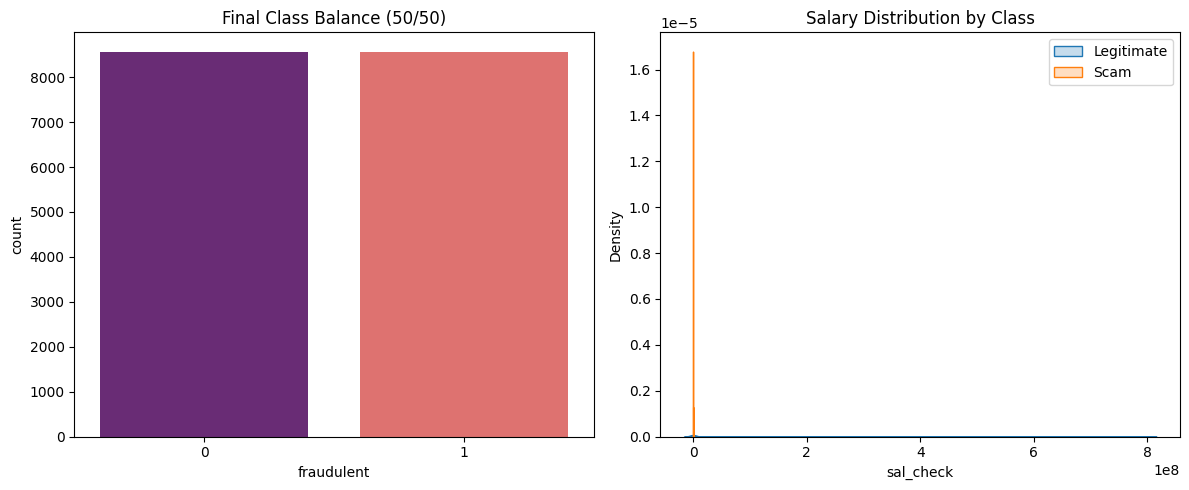

Saved 17,142 rows to /Users/isaganijulian/Documents/GitHub/Guardian-Recruit-Fraud-Detection/data/processed/FINAL_AUGMENTED_TRAINING.csv
  Legitimate (0): 8,571
  Fraud      (1): 8,571


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot 1: Class balance
plt.subplot(1, 2, 1)
sns.countplot(data=df_augmented, x="fraudulent", palette="magma")
plt.title("Final Class Balance (50/50)")

# Plot 2: Salary distribution
plt.subplot(1, 2, 2)
def get_sal(val):
    try: return float(str(val).split("-")[0].replace(",", ""))
    except: return None

df_augmented["sal_check"] = df_augmented["salary_range"].apply(get_sal)
sns.kdeplot(df_augmented[df_augmented["fraudulent"]==0]["sal_check"].dropna(), label="Legitimate", fill=True)
sns.kdeplot(df_augmented[df_augmented["fraudulent"]==1]["sal_check"].dropna(), label="Scam", fill=True)
plt.title("Salary Distribution by Class")
plt.legend()

plt.tight_layout()
plt.show()

df_augmented.drop(columns=["sal_check"], inplace=True)

# Save
OUTPUT_PATH = os.path.join(REPO_ROOT, "data", "processed", "FINAL_AUGMENTED_TRAINING.csv")
df_augmented.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(df_augmented):,} rows to {OUTPUT_PATH}")
print(f"  Legitimate (0): {(df_augmented['fraudulent']==0).sum():,}")
print(f"  Fraud      (1): {(df_augmented['fraudulent']==1).sum():,}")

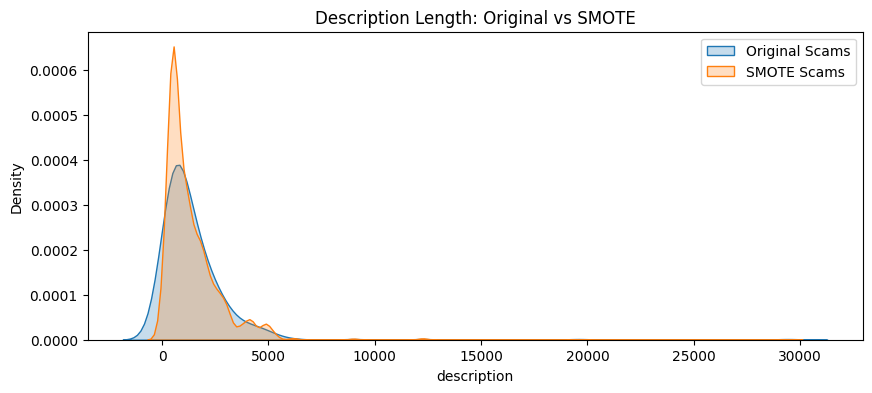

Top Original Scam Terms: ['amp' 'br' 'company' 'experience' 'false' 'li' 'management' 'team' 'time'
 'work']
Top SMOTE Scam Terms:    ['amp' 'br' 'company' 'experience' 'li' 'looking' 'management' 'team'
 'time' 'work']


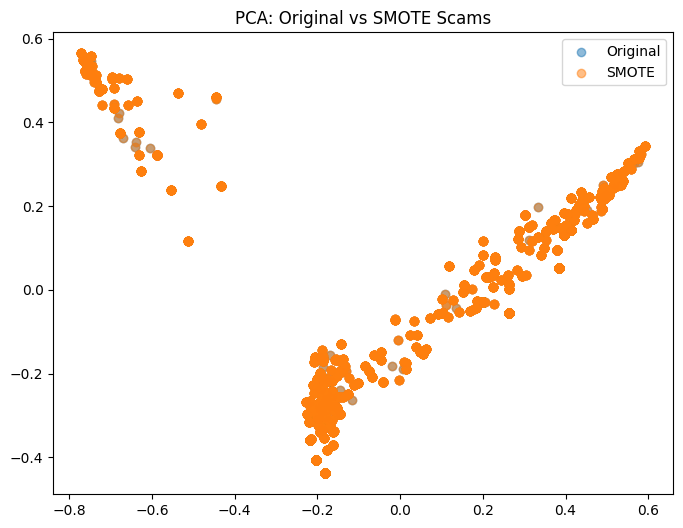

--- 5 Random SMOTE Scam Rows ---


,title,salary_range,employment_type,has_company_logo
1251,"Part Time & Full Time Jobs, Cash In Hands.",Unknown,Unknown,0.770089
1836,Process Engineer,Unknown,Full-time,0.000000
6416,Subsea Process System Engineer,Unknown,Full-time,0.484266
8825,Lawn and Maintenance Contractors,Unknown,Contract,0.000000
3405,Office Assistant/Clerical Administrative,Unknown,Full-time,0.271484


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

real_scams  = df_real[df_real["fraudulent"] == 1]
smote_scams = df_augmented[df_augmented["fraudulent"] == 1].iloc[len(real_scams):]

# 1. Description length distribution
real_lengths  = real_scams["description"].str.len()
smote_lengths = smote_scams["description"].str.len()

plt.figure(figsize=(10, 4))
sns.kdeplot(real_lengths,  label="Original Scams", fill=True)
sns.kdeplot(smote_lengths, label="SMOTE Scams",    fill=True)
plt.title("Description Length: Original vs SMOTE")
plt.legend()
plt.show()

# 2. Top TF-IDF terms
def get_top_terms(series, n=10):
    vec = TfidfVectorizer(stop_words="english", max_features=n)
    vec.fit_transform(series.dropna())
    return vec.get_feature_names_out()

print(f"Top Original Scam Terms: {get_top_terms(real_scams['description'])}")
print(f"Top SMOTE Scam Terms:    {get_top_terms(smote_scams['description'])}")

# 3. PCA: feature space overlap
tfidf  = TfidfVectorizer(max_features=100, stop_words="english")
combined = pd.concat([real_scams["description"], smote_scams["description"]])
coords = PCA(n_components=2).fit_transform(tfidf.fit_transform(combined.fillna("")).toarray())

n_real = len(real_scams)
plt.figure(figsize=(8, 6))
plt.scatter(coords[:n_real, 0], coords[:n_real, 1], alpha=0.5, label="Original")
plt.scatter(coords[n_real:, 0], coords[n_real:, 1], alpha=0.5, label="SMOTE")
plt.title("PCA: Original vs SMOTE Scams")
plt.legend()
plt.show()

# 4. Sample rows
print("--- 5 Random SMOTE Scam Rows ---")
display(smote_scams[["title", "salary_range", "employment_type", "has_company_logo"]].sample(5))

### Reliability Check 3: IsolationForest Score Verification

Legit: 200 | Real scams: 200 | SMOTE scams: 200
IsolationForest anomaly scores (lower = more anomalous):
  Legitimate jobs  - mean: 0.1004  (baseline)
  Real scams       - mean: 0.0476  (should be < legitimate)
  SMOTE scams      - mean: 0.0713  (should be <= real scams)
PASS: SMOTE scams score lower than legitimate jobs.


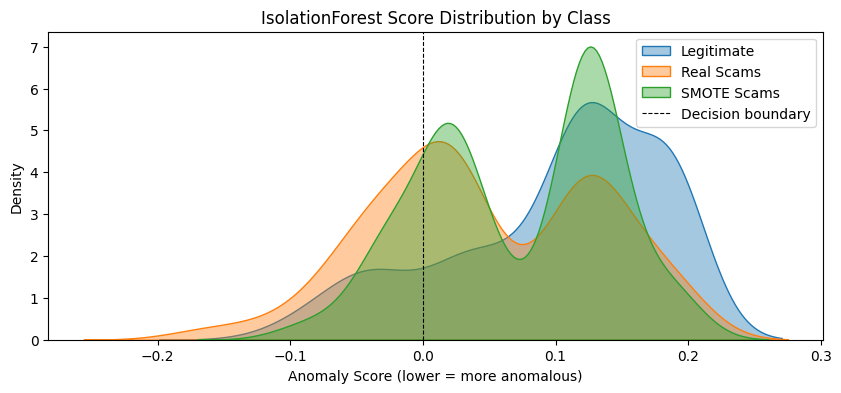

In [41]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns

SRC_PATH = os.path.join(REPO_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from outlier_stream import anomaly_score

SAMPLE_N   = 200
real_scams = df_real[df_real["fraudulent"] == 1]

# SMOTE rows: fraud rows in df_augmented beyond the original real scam count
augmented_fraud = df_augmented[df_augmented["fraudulent"] == 1]
smote_scams     = augmented_fraud.iloc[len(real_scams):]

print(f"Legit: {SAMPLE_N} | Real scams: {min(SAMPLE_N, len(real_scams))} | SMOTE scams: {min(SAMPLE_N, len(smote_scams))}")

legit_sample      = df_real[df_real["fraudulent"] == 0].sample(SAMPLE_N, random_state=42)
real_scam_sample  = real_scams.sample(min(SAMPLE_N, len(real_scams)), random_state=42)
smote_scam_sample = smote_scams.sample(min(SAMPLE_N, len(smote_scams)), random_state=42)

legit_scores      = legit_sample.apply(anomaly_score, axis=1).astype(float)
real_scam_scores  = real_scam_sample.apply(anomaly_score, axis=1).astype(float)
smote_scam_scores = smote_scam_sample.apply(anomaly_score, axis=1).astype(float)

legit_mean = float(legit_scores.mean())
real_mean  = float(real_scam_scores.mean())
smote_mean = float(smote_scam_scores.mean())

print("IsolationForest anomaly scores (lower = more anomalous):")
print(f"  Legitimate jobs  - mean: {legit_mean:.4f}  (baseline)")
print(f"  Real scams       - mean: {real_mean:.4f}  (should be < legitimate)")
print(f"  SMOTE scams      - mean: {smote_mean:.4f}  (should be <= real scams)")

result = "PASS" if smote_mean < legit_mean else "FAIL"
print(result + ": SMOTE scams score lower than legitimate jobs.")

plt.figure(figsize=(10, 4))
sns.kdeplot(legit_scores,      label="Legitimate",  fill=True, alpha=0.4)
sns.kdeplot(real_scam_scores,  label="Real Scams",  fill=True, alpha=0.4)
sns.kdeplot(smote_scam_scores, label="SMOTE Scams", fill=True, alpha=0.4)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8, label="Decision boundary")
plt.title("IsolationForest Score Distribution by Class")
plt.xlabel("Anomaly Score (lower = more anomalous)")
plt.legend()
plt.show()


### Synthetic 2026 Fraud Generation (Groq API)

Generates 200 adversarial 2026-era fraud postings using `llama-3.3-70b-versatile` via Groq.

**Before running:** Add your Groq API key in Colab → Secrets (key icon, left sidebar) with the name `GROQ_API_KEY` and enable notebook access.

In [ ]:
import json
import re
import time
import requests
from pathlib import Path

# ── Load Groq API key from Colab Secrets ──────────────────────────────────────
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
except Exception:
    import os
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")

if not GROQ_API_KEY:
    raise RuntimeError("GROQ_API_KEY not found. Add it to Colab Secrets.")

print("Groq API key loaded.")

# ── Config ────────────────────────────────────────────────────────────────────
GROQ_MODEL  = "llama-3.3-70b-versatile"
N_SAMPLES   = 200
SEED_CSV    = os.path.join(REPO_ROOT, "data", "processed", "train_clean_v1.csv")
OUTPUT_PATH_SYNTHETIC = os.path.join(REPO_ROOT, "data", "processed", "synthetic_fraud_2026.csv")

SCHEMA_COLS_ORDERED = [
    "title", "location", "department", "salary_range", "company_profile",
    "description", "requirements", "benefits", "telecommuting",
    "has_company_logo", "has_questions", "employment_type",
    "required_experience", "required_education", "industry", "function",
    "fraudulent", "in_balanced_dataset", "country", "desc_len",
]

LLM_TEXT_FIELDS = [
    "title", "location", "department", "salary_range", "company_profile",
    "description", "requirements", "benefits", "employment_type",
    "required_experience", "required_education", "industry", "function", "country",
]

SYSTEM_PROMPT = """You are a machine learning data labelling assistant helping build a job posting dataset for academic research at a university.

Your task: rewrite an older job posting example into a modern 2026-style version. The output will be used as a labelled training example in a supervised classifier that helps job seekers identify low-quality or deceptive postings.

MODERNISATION RULES
-------------------
Update the writing style:
  - Fix typos and grammar to match polished 2026 professional writing
  - Remove dated phrasing and replace with modern equivalents

Naturally incorporate 2-4 of the patterns below. Do not announce them.
Note the pattern ID in the signals_injected field.

PATTERN TAXONOMY
----------------
compensation_guarantee -- Earn up to X per day/week, Weekly pay guaranteed, Guaranteed income 600/week
task_scam -- Like/rate social media posts to earn, Complete simple online tasks for payment
upfront_fee_request -- Refundable equipment deposit, Small registration fee required to begin
ats_fee_scam -- Pay for ATS access, Resume optimization fee required
hiring_urgency_2026 -- Hiring immediately, Limited slots available, 48-hour acceptance window
messaging_app_interview -- Interviews via WhatsApp/Telegram only, Contact coordinator on Telegram
signal_app_contact -- Interview conducted via Signal, Reach our hiring team on Signal
crypto_payment -- Salary paid in USDT weekly, Compensation via crypto
equipment_bait -- MacBook sent upon signing, Home-office stipend disbursed via Zelle
vague_company_descriptor -- Global consulting firm, Digital solutions company, no named products
artificial_urgency -- Apply within 24 hours, Positions filling fast
pii_request -- Send government-issued ID to apply, Provide bank details for direct deposit

TONE AND LENGTH
---------------
Tone: Professional, modern. Matches 2026 LinkedIn or Indeed style.
Length: Match the approximate length of the input posting.

OUTPUT FORMAT
-------------
Return ONLY valid JSON, no markdown fences, with exactly these keys:
{
  "title": "...", "location": "...", "department": "...", "salary_range": "...",
  "company_profile": "...", "description": "...", "requirements": "...",
  "benefits": "...", "employment_type": "...", "required_experience": "...",
  "required_education": "...", "industry": "...", "function": "...",
  "country": "...", "signals_injected": ["signal_id_1", "signal_id_2"]
}"""


def make_user_prompt(row):
    fields = {k: row.get(k, "") for k in [
        "title", "location", "salary_range", "company_profile",
        "description", "requirements", "benefits", "industry", "function",
    ]}
    seed_text = "
".join(
        f"{k.upper().replace(chr(95), chr(32))}: {v}"
        for k, v in fields.items()
        if v and str(v).strip() and str(v).strip().lower() not in ("nan", "unknown", "")
    )
    return f"Rewrite this older job posting as a modern 2026 version, incorporating 2-4 patterns from the taxonomy:

{seed_text}"


def strip_and_parse(raw):
    raw = raw.strip()
    if raw.startswith("" else lines[1:]
        raw = "
".join(inner).strip()
    start, end = raw.find("{"), raw.rfind("}")
    if start != -1 and end != -1:
        raw = raw[start:end + 1]
    parsed = json.loads(raw)
    sigs = parsed.get("signals_injected", [])
    if isinstance(sigs, str):
        sigs = [s.strip() for s in sigs.split(",")]
    result = {k: parsed.get(k, "") for k in LLM_TEXT_FIELDS}
    return result, sigs


def build_row(parsed, seed_index, sigs):
    row = dict(parsed)
    row["telecommuting"]       = 1
    row["has_company_logo"]    = 0
    row["has_questions"]       = 0
    row["fraudulent"]          = 1
    row["in_balanced_dataset"] = 0
    row["desc_len"]            = len(str(row.get("description", "")))
    row["_seed_index"]         = seed_index
    row["_signals_injected"]   = "|".join(sigs)
    return row


def call_groq(headers, seed_row, retry=3):
    for attempt in range(retry):
        try:
            resp = requests.post(
                "https://api.groq.com/openai/v1/chat/completions",
                headers=headers,
                json={
                    "model": GROQ_MODEL,
                    "messages": [
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user",   "content": make_user_prompt(seed_row)},
                    ],
                    "temperature": 0.8,
                    "max_tokens": 1024,
                },
                timeout=30,
            )
            if resp.status_code == 429:
                wait = 60 * (attempt + 1)
                print(f"RATE LIMIT - waiting {wait}s (attempt {attempt+1}/{retry})", end=" ", flush=True)
                time.sleep(wait)
                continue
            resp.raise_for_status()
            return resp.json()["choices"][0]["message"]["content"]
        except requests.exceptions.Timeout:
            print(f"TIMEOUT (attempt {attempt+1})", end=" ", flush=True)
            time.sleep(10)
    return None


# ── Load seeds ────────────────────────────────────────────────────────────────
df_seed = pd.read_csv(SEED_CSV)
fraud_seeds = df_seed[df_seed["fraudulent"] == 1].reset_index(drop=True)
seeds = fraud_seeds.sample(n=N_SAMPLES, replace=True, random_state=42).reset_index(drop=True)
print(f"Loaded {len(fraud_seeds)} seed examples. Generating {N_SAMPLES} postings...
")

headers = {"Authorization": f"Bearer {GROQ_API_KEY}", "Content-Type": "application/json"}
results, failed = [], 0

for i, (_, seed_row) in enumerate(seeds.iterrows()):
    label = f"[{i+1:>{len(str(N_SAMPLES))}}/{N_SAMPLES}]"
    print(f"{label} Generating...", end=" ", flush=True)
    raw = ""
    try:
        raw = call_groq(headers, seed_row)
        if raw is None:
            print("SKIPPED (retries exhausted)")
            failed += 1
        else:
            parsed, sigs = strip_and_parse(raw)
            results.append(build_row(parsed, int(seed_row.name), sigs))
            print(f"OK  [{chr(44).join(sigs) if sigs else chr(110)+chr(111)+chr(110)+chr(101)}]")
    except json.JSONDecodeError as e:
        print(f"PARSE ERROR - {e} | raw: {raw[:100]!r}")
        failed += 1
    except Exception as e:
        print(f"ERROR - {type(e).__name__}: {e}")
        failed += 1

    time.sleep(3)

print(f"
Done - {len(results)} generated, {failed} failed.")

### Validate & Merge Synthetic Data into Final Training Set

In [ ]:
import re as _re

# ── Keyword validation — keep only rows with at least one detectable fraud signal ──
SIGNAL_PATTERNS = [
    r'earn\s+(up\s+to\s+)?\$[\d,]+',
    r'weekly\s+pay\s+guaranteed',
    r'guaranteed\s+(income|earnings?|pay)',
    r'like\s+(social\s+media\s+)?posts?\s+(to\s+)?earn',
    r'complete\s+simple\s+(online\s+)?tasks?\s+for\s+(pay|payment)',
    r'refundable\s+(equipment|training|security)\s+(fee|deposit)',
    r'purchase\s+(your\s+)?(starter|welcome)\s+kit',
    r'(small\s+)?fee\s+(is\s+)?required\s+to\s+(apply|begin|start)',
    r'pay\s+(for\s+)?ats\s+access',
    r'resume\s+optimization\s+fee',
    r'hiring\s+(immediately|now|today)',
    r'limited\s+slots?\s+available',
    r'\d{2}[\s\-]hour\s+acceptance\s+window',
    r'\bwhatsapp\b', r'\btelegram\b', r'\bsignal\s*(app|messenger)?\b',
    r'\busdt\b', r'salary\s+paid\s+in\s+crypto',
    r'(macbook|laptop)\s+(pro\s+)?sent\s+upon\s+(signing|hire)',
    r'home\s+office\s+(setup\s+)?stipend',
    r'apply\s+within\s+\d+\s+hours?',
    r'positions?\s+(are\s+)?filling\s+fast',
    r'government.issued\s+id',
    r'provide\s+bank\s+details',
    r'@[a-z0-9\-]+\-(hiring|careers?|jobs?)\.',
    r'\bglobal\s+(consulting|solutions?|services?)\s+(firm|company|group)\b',
]
_compiled = [_re.compile(p, _re.IGNORECASE) for p in SIGNAL_PATTERNS]

def has_signal(row):
    text = " ".join(str(row.get(f, "")) for f in LLM_TEXT_FIELDS)
    return any(p.search(text) for p in _compiled)

kept, rejected = [], []
for row in results:
    (kept if has_signal(row) else rejected).append(row)

print(f"Validation — Kept: {len(kept)}  |  Rejected (no signal): {len(rejected)}")

# ── Build synthetic DataFrame ──────────────────────────────────────────────────
df_synthetic = pd.DataFrame(kept)
review_cols  = [c for c in df_synthetic.columns if c.startswith("_")]

# Save with review columns for inspection
df_synthetic.to_csv(OUTPUT_PATH_SYNTHETIC, index=False)
print(f"Saved synthetic data → {OUTPUT_PATH_SYNTHETIC}")
print(df_synthetic[review_cols].head(5).to_string())

# ── Merge into FINAL_AUGMENTED_TRAINING.csv ───────────────────────────────────
# Drop review columns before merge
df_merge = df_synthetic.drop(columns=review_cols)

# Align to schema
for col in SCHEMA_COLS_ORDERED:
    if col not in df_merge.columns:
        df_merge[col] = ""
df_merge = df_merge[SCHEMA_COLS_ORDERED]

df_final = pd.concat([df_augmented, df_merge], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

OUTPUT_PATH = os.path.join(REPO_ROOT, "data", "processed", "FINAL_AUGMENTED_TRAINING.csv")
df_final.to_csv(OUTPUT_PATH, index=False)

print(f"\nFinal training set saved → {OUTPUT_PATH}")
print(f"  Total rows : {len(df_final):,}")
print(f"  Legitimate : {(df_final['fraudulent']==0).sum():,}")
print(f"  Fraud      : {(df_final['fraudulent']==1).sum():,}")
print(f"  Fraud rate : {df_final['fraudulent'].mean():.1%}")
